# Synthetic 3D Shapes → kNN Graphs → GNN Classification (GCN / GraphSAGE / GAT) 



In [1]:
import math, random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_undirected
from torch_geometric.nn import global_mean_pool, GCNConv, SAGEConv, GATConv

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available(), "| device:", device)

torch.manual_seed(0)
random.seed(0)


torch: 2.8.0 | cuda: False | device: cpu


## 1) kNN graph builder (pure PyTorch)

We build kNN using `torch.cdist` → **O(N²)**, so keep `num_points` moderate (e.g., 128–512).


In [2]:
def knn_graph_torch(pos: torch.Tensor, k: int, loop: bool = False) -> torch.Tensor:
    # pos: [N, 3]
    dist = torch.cdist(pos, pos)  # [N, N]
    if not loop:
        dist.fill_diagonal_(float("inf"))
    knn = dist.topk(k, largest=False).indices  # [N, k]
    row = torch.arange(pos.size(0), device=pos.device).view(-1, 1).repeat(1, k).reshape(-1)
    col = knn.reshape(-1)
    return torch.stack([row, col], dim=0)  # [2, N*k]


## 2) Shape samplers (point clouds)

We sample points on:
- sphere surface
- cube surface
- cylinder surface 


In [3]:
def sample_sphere(n, r=1.0):
    x = torch.randn(n, 3)
    x = x / (x.norm(dim=1, keepdim=True) + 1e-9)
    return r * x

def sample_cube_surface(n, a=1.0):
    pts = []
    for _ in range(n):
        face = random.randint(0, 5)
        u = (torch.rand(1).item() * 2 - 1) * a
        v = (torch.rand(1).item() * 2 - 1) * a
        if face == 0:  pts.append([ a, u, v])
        if face == 1:  pts.append([-a, u, v])
        if face == 2:  pts.append([u,  a, v])
        if face == 3:  pts.append([u, -a, v])
        if face == 4:  pts.append([u, v,  a])
        if face == 5:  pts.append([u, v, -a])
    return torch.tensor(pts, dtype=torch.float32)

def sample_cylinder(n, r=1.0, h=2.0):
    pts = []
    for _ in range(n):
        part = random.random()
        if part < 0.7:
            theta = random.random() * 2 * math.pi
            z = (random.random() - 0.5) * h
            x = r * math.cos(theta)
            y = r * math.sin(theta)
            pts.append([x, y, z])
        else:
            theta = random.random() * 2 * math.pi
            rad = math.sqrt(random.random()) * r
            x = rad * math.cos(theta)
            y = rad * math.sin(theta)
            z = (h / 2) if random.random() < 0.5 else (-h / 2)
            pts.append([x, y, z])
    return torch.tensor(pts, dtype=torch.float32)


## 3) Augmentations  

- Random rotation around z-axis  
- Small Gaussian jitter


In [4]:
def random_rotation_z(pos):
    ang = random.random() * 2 * math.pi
    c, s = math.cos(ang), math.sin(ang)
    R = torch.tensor([[c, -s, 0],
                      [s,  c, 0],
                      [0,  0, 1]], dtype=pos.dtype)
    return pos @ R.T

def jitter(pos, sigma=0.02):
    return pos + sigma * torch.randn_like(pos)


## 4) Synthetic dataset (offline)

Each sample:
- generates a point cloud `pos` of size `num_points`
- creates a kNN graph `edge_index`
- assigns semantic label `y` (0..C-1)

Choose shapes with `shapes=(...)`.


In [5]:
class SyntheticShapes(Dataset):
    def __init__(self, num_graphs=600, num_points=256, k=12,
                 shapes=("sphere", "cube", "cylinder"),
                 augment=True):
        self.num_graphs = num_graphs
        self.num_points = num_points
        self.k = k
        self.shapes = list(shapes)
        self.augment = augment
        self.class_to_shape = {i: s for i, s in enumerate(self.shapes)}

    def __len__(self):
        return self.num_graphs

    def __getitem__(self, idx):
        y = random.randint(0, len(self.shapes) - 1)
        shape = self.class_to_shape[y]

        if shape == "sphere":
            pos = sample_sphere(self.num_points, r=1.0)
        elif shape == "cube":
            pos = sample_cube_surface(self.num_points, a=1.0)
        elif shape == "cylinder":
            pos = sample_cylinder(self.num_points, r=1.0, h=2.0)
        else:
            raise ValueError(shape)

        if self.augment:
            pos = random_rotation_z(pos)
            pos = jitter(pos, sigma=0.02)

        edge_index = to_undirected(knn_graph_torch(pos, k=self.k, loop=False))
        return Data(pos=pos, edge_index=edge_index, y=torch.tensor([y], dtype=torch.long))


## 5) Visualization helpers

In [6]:
def visualize_points_3d(pos, edge_index=None, title="", max_edges=1500):
    pos = pos.detach().cpu()
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pos[:,0], pos[:,1], pos[:,2], s=10, alpha=0.85)
    if edge_index is not None:
        ei = edge_index.detach().cpu()
        E = ei.size(1)
        for j in range(min(E, max_edges)):
            a = int(ei[0,j]); b = int(ei[1,j])
            p1, p2 = pos[a], pos[b]
            ax.plot([p1[0],p2[0]],[p1[1],p2[1]],[p1[2],p2[2]], linewidth=0.3, alpha=0.2)
    ax.set_title(title)
    ax.set_box_aspect([1,1,1])
    plt.tight_layout()
    plt.show()


## 6) Create train/test split (2 or 3 classes)

Set `shapes=(...)` to choose classes:
- 2 classes: `("sphere","cube")`
- 3 classes: `("sphere","cube","cylinder")`


num_classes: 3 ['sphere', 'cube', 'cylinder']
example: Data(edge_index=[2, 3408], y=[1], pos=[256, 3])


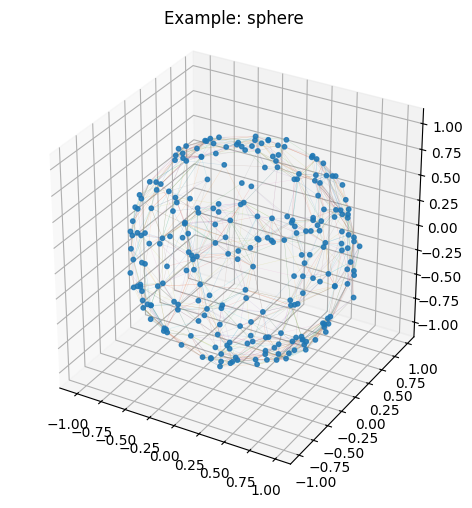

In [8]:
# ---- choose classes here ----
shapes = ("sphere", "cube", "cylinder")  # change to ("sphere","cube") for 2 classes

num_points = 256
k = 12

full_ds = SyntheticShapes(num_graphs=900, num_points=num_points, k=k, shapes=shapes, augment=True)

# simple split
perm = torch.randperm(len(full_ds))
n_train = int(0.8 * len(full_ds))
train_idx = perm[:n_train].tolist()
test_idx  = perm[n_train:].tolist()

train_ds = [full_ds[i] for i in train_idx]
test_ds  = [full_ds[i] for i in test_idx]

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

num_classes = len(shapes)
class_names = list(shapes)
print("num_classes:", num_classes, class_names)
print("example:", train_ds[0])
visualize_points_3d(train_ds[0].pos, train_ds[0].edge_index, title=f"Example: {class_names[int(train_ds[0].y)]}")


## 7) ShapeClassifier (GCN / SAGE / GAT)

Graph-level classification:
- node features: `pos` (x,y,z)
- edges: kNN graph
- readout: `global_mean_pool`


In [9]:
class ShapeClassifier(nn.Module):
    def __init__(self, in_dim=3, hid=64, num_classes=3, kind="sage"):
        super().__init__()
        if kind == "gcn":
            self.c1, self.c2 = GCNConv(in_dim, hid), GCNConv(hid, hid)
        elif kind == "sage":
            self.c1, self.c2 = SAGEConv(in_dim, hid), SAGEConv(hid, hid)
        elif kind == "gat":
            self.c1 = GATConv(in_dim, hid, heads=4, concat=True, dropout=0.1)
            self.c2 = GATConv(hid*4, hid, heads=1, concat=False, dropout=0.1)
        else:
            raise ValueError(f"Unknown kind: {kind}")

        self.lin = nn.Linear(hid, num_classes)

    def encode_nodes(self, batch):
        x = batch.pos
        x = F.relu(self.c1(x, batch.edge_index))
        x = F.relu(self.c2(x, batch.edge_index))
        return x  # [num_nodes, hid]

    def embed_graph(self, batch):
        x = self.encode_nodes(batch)
        g = global_mean_pool(x, batch.batch)  # [num_graphs, hid]
        return g

    def forward(self, batch):
        g = self.embed_graph(batch)
        return self.lin(g)  # [num_graphs, num_classes]


## 8) Train + evaluate accuracy

In [10]:
@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    correct = total = 0
    for b in loader:
        b = b.to(device)
        logits = model(b)
        y = b.y.view(-1).long()
        pred = logits.argmax(dim=-1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct/total if total > 0 else 0.0

def train_model(kind="sage", hid=64, epochs=30, lr=1e-3, wd=1e-4):
    model = ShapeClassifier(hid=hid, num_classes=num_classes, kind=kind).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    for ep in range(1, epochs+1):
        model.train()
        tot = 0.0
        for b in train_loader:
            b = b.to(device)
            y = b.y.view(-1).long()
            logits = model(b)
            loss = loss_fn(logits, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            tot += loss.item()

        if ep == 1 or ep % 5 == 0:
            tr = eval_acc(model, train_loader)
            te = eval_acc(model, test_loader)
            print(f"{kind.upper()} | ep {ep:03d} | loss {tot/len(train_loader):.3f} | train {tr:.3f} | test {te:.3f}")
    return model

kind = "sage"  # try: "gcn", "sage", "gat"
model = train_model(kind=kind, hid=64, epochs=30, lr=1e-3, wd=1e-4)


SAGE | ep 001 | loss 1.093 | train 0.338 | test 0.328
SAGE | ep 005 | loss 0.874 | train 0.679 | test 0.622
SAGE | ep 010 | loss 0.405 | train 1.000 | test 1.000
SAGE | ep 015 | loss 0.206 | train 1.000 | test 1.000
SAGE | ep 020 | loss 0.102 | train 1.000 | test 1.000
SAGE | ep 025 | loss 0.056 | train 1.000 | test 1.000
SAGE | ep 030 | loss 0.034 | train 1.000 | test 1.000


## 9) Confusion matrix (test set)

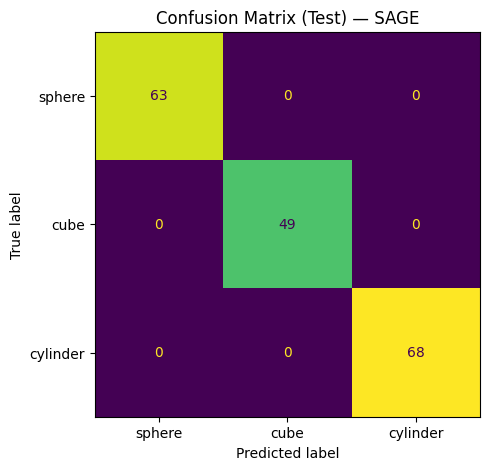

test accuracy: 1.0


In [11]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    ys, ps = [], []
    for b in loader:
        b = b.to(device)
        logits = model(b)
        pred = logits.argmax(dim=-1).cpu()
        y = b.y.view(-1).cpu()
        ys.append(y); ps.append(pred)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

y_true, y_pred = predict_all(model, test_loader)
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap=None, colorbar=False)
plt.title(f"Confusion Matrix (Test) — {kind.upper()}")
plt.show()

print("test accuracy:", (y_true == y_pred).mean())


## 10) t-SNE of graph embeddings

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/pyth

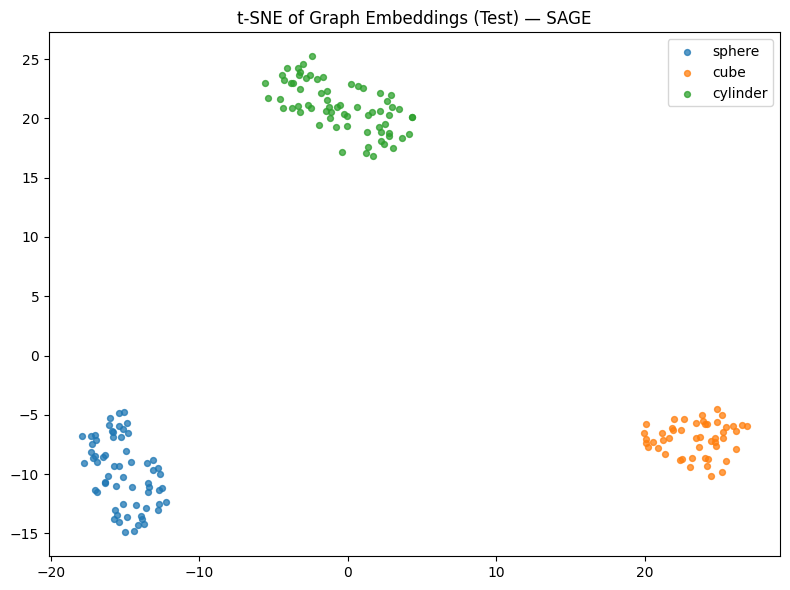

In [12]:
@torch.no_grad()
def collect_graph_embeddings(model, loader, max_batches=None):
    model.eval()
    embs, labels = [], []
    for bi, b in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        b = b.to(device)
        g = model.embed_graph(b)          # [B, hid]
        embs.append(g.cpu())
        labels.append(b.y.view(-1).cpu())
    embs = torch.cat(embs).numpy()
    labels = torch.cat(labels).numpy()
    return embs, labels

embs, labels = collect_graph_embeddings(model, test_loader)

tsne = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=25)
emb2d = tsne.fit_transform(embs)

plt.figure(figsize=(8,6))
for c in range(num_classes):
    idx = labels == c
    plt.scatter(emb2d[idx,0], emb2d[idx,1], s=18, alpha=0.75, label=class_names[c])
plt.legend()
plt.title(f"t-SNE of Graph Embeddings (Test) — {kind.upper()}")
plt.tight_layout()
plt.show()


## 11) Optional: compare GCN vs SAGE vs GAT quickly

In [ ]:
# Uncomment to train and compare all three quickly.
# models = {}
# for knd in ["gcn", "sage", "gat"]:
#     models[knd] = train_model(kind=knd, hid=64, epochs=20, lr=1e-3, wd=1e-4)
#     print(knd, "test acc", eval_acc(models[knd], test_loader))
